# Exploración de datos

## 1. Contexto y objetivo
El objetivo de este proyecto es analizar la producción de petróleo de pozos no convencionales de Argentina y explorar si las características de los pozos y su historial de producción permiten predecir su comportamiento productivo futuro.

La pregunta principal que buscamos responder es:

> **Dadas las características de un pozo y su historial de producción, ¿cuánto petróleo esperamos que produzca el próximo mes?**

A partir de esta pregunta se plantean tres enfoques de Machine Learning:

- **Regresión:** predecir la cantidad de petróleo que producirá un pozo durante el próximo mes.
- **Clasificación:** categorizar la producción futura del pozo en diferentes niveles de producción.
- **Clustering:** identificar grupos de pozos con características y comportamientos productivos similares.

En esta primera etapa del proyecto realizaremos una exploración de los datos disponibles, buscando comprender su estructura, calidad, variables relevantes y relaciones entre las diferentes fuentes de información.

### Importación de librerías

Para realizar el análisis exploratorio utilizaremos principalmente **Pandas**, **NumPy** y **Matplotlib**.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Indicamos que se visualicen todas las columnas del dataframe
pd.set_option("display.max_columns", None)

### Carga de los datasets

Para el análisis utilizaremos tres fuentes principales de información:

1. **Producción no convencional:** contiene registros mensuales de producción de petróleo, gas, agua y otras variables asociadas a los pozos no convencionales.
2. **Características de los pozos:** contiene información descriptiva de los pozos, como profundidad, formación, cuenca, tipo de recurso y tipo de extracción.
3. **Fracturación:** contiene información relacionada con las operaciones de fracturación de los pozos, incluyendo cantidad de fracturas, longitud de la rama horizontal, arena y agua utilizadas, entre otras variables.

Los archivos originales se mantienen sin modificar dentro de `data/raw/`.

In [3]:
produccion = pd.read_csv(
    "../data/raw/produccin-de-pozos-de-gas-y-petrleo-no-convencional.csv"
)

pozos = pd.read_csv(
    "../data/raw/capitulo-iv-pozos.csv"
)

fracturacion = pd.read_csv(
    "../data/raw/datos-de-fractura-de-pozos-de-hidrocarburos-adjunto-iv-actualizacin-diaria.csv"
)

## 2. Inspección inicial de los datasets

En esta primera etapa queremos conocer la estructura general de los datasets y verificar que los archivos hayan sido importados correctamente.

Antes de realizar transformaciones o eliminar datos, analizaremos:

- la cantidad de filas y columnas de cada dataset;
- los nombres de las variables disponibles;
- los tipos de datos;
- una muestra de los registros;
- la presencia de valores nulos;
- la existencia de registros duplicados.

Esta inspección inicial nos permitirá comprender qué información contiene cada fuente y detectar posibles problemas de calidad que deberán ser considerados durante las etapas posteriores del análisis.

> **Importante:** en esta etapa no eliminaremos datos automáticamente. Primero analizaremos qué representan y si los valores faltantes, ceros o duplicados tienen un significado dentro del problema.

### 2.1 Dimensiones de los datasets

Comenzamos revisando las dimensiones de cada dataset.

El atributo `shape` de Pandas devuelve una tupla con la siguiente estructura:

```text
(filas, columnas)

In [4]:
resumen_dimensiones = pd.DataFrame({
    "Dataset": [
        "Producción no convencional",
        "Pozos",
        "Fracturación"
    ],
    "Filas": [
        produccion.shape[0],
        pozos.shape[0],
        fracturacion.shape[0]
    ],
    "Columnas": [
        produccion.shape[1],
        pozos.shape[1],
        fracturacion.shape[1]
    ]
})

display(resumen_dimensiones)

,Dataset,Filas,Columnas
0,Producción no convencional,421046,40
1,Pozos,85611,26
2,Fracturación,4890,30


### 2.2. Nombres de las variables

Una vez conocidas las dimensiones de los datasets, analizamos las variables disponibles en cada fuente.

Conocer los nombres de las columnas nos permite identificar qué tipo de información contiene cada dataset y comenzar a determinar qué variables podrían ser relevantes para nuestro problema de predicción.

En particular, nos interesa identificar:

- variables que describan las características de los pozos;
- variables relacionadas con la producción;
- variables temporales, como año y mes;
- variables relacionadas con la fracturación;
- identificadores que permitan relacionar los diferentes datasets.

En esta etapa solamente identificaremos las variables disponibles.

In [5]:
columnas_datasets = pd.DataFrame({
    "Producción": pd.Series(produccion.columns),
    "Pozos": pd.Series(pozos.columns),
    "Fracturación": pd.Series(fracturacion.columns)
})

display(columnas_datasets)

,Producción,Pozos,Fracturación
0,idempresa,sigla,id_base_fractura_adjiv
1,anio,idpozo,idpozo
2,mes,area,sigla
3,idpozo,cod_area,cuenca
4,prod_pet,empresa,areapermisoconcesion
5,prod_gas,yacimiento,yacimiento
6,prod_agua,cod_yacimiento,formacion_productiva
7,iny_agua,formacion,tipo_reservorio
8,iny_gas,cuenca,subtipo_reservorio
9,iny_co2,provincia,longitud_rama_horizontal_m


### 2.3. Primer vistazo a los registros

Los nombres de las columnas nos permiten conocer qué variables están disponibles, pero todavía no muestran cómo están representados los datos.

Para obtener una primera visión del contenido de cada dataset utilizaremos `head()`, que permite visualizar los primeros registros.

Esta inspección nos ayuda a:

- comprobar que los datos fueron cargados correctamente;
- observar el formato de los valores;
- identificar posibles inconsistencias evidentes;
- relacionar los nombres de las variables con los valores que contienen.

La visualización de los primeros registros no implica que estos sean representativos de todo el dataset. Se utiliza únicamente como una primera inspección.

In [6]:
print("Primeros registros del dataset de producción:")
display(produccion.head())

Primeros registros del dataset de producción:


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,iny_otro,tef,vida_util,tipoextraccion,tipoestado,tipopozo,observaciones,fechaingreso,rectificado,habilitado,idusuario,empresa,sigla,formprod,profundidad,formacion,idareapermisoconcesion,areapermisoconcesion,idareayacimiento,areayacimiento,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,YSUR,2015,1,132909,16.74,241.220,13.42,0.0,0.0,0.0,0.0,31.00,NaN,Plunger Lift,Extracción Efectiva,Gasífero,NaN,2015-02-26 13:35:35.533458,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,AEA.NQ.RCo-1039,PREC,2678.0,precuyo,SDD,AL SUR DE LA DORSAL,RQC,RANQUIL CO,NEUQUINA,Neuquén,-69.202207,-39.081820,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2015-01-31
1,YSUR,2018,1,132488,0.00,171.937,0.00,0.0,0.0,0.0,0.0,30.73,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2018-02-10 08:37:14.717426,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,AEA.RN.EFO-99(d),LAJA,3828.0,lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.864960,-39.016722,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
2,YSUR,2017,1,134325,22.34,365.610,1.20,0.0,0.0,0.0,0.0,31.00,NaN,Plunger Lift,Extracción Efectiva,Gasífero,NaN,2017-02-16 13:45:37.233373,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-117(d),LAJA,3793.0,lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.849735,-39.020644,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31
3,YSUR,2018,1,132487,0.00,514.696,17.00,0.0,0.0,0.0,0.0,29.90,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2018-02-10 08:37:14.717426,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-139(d),FIMP,2707.0,formación improductiva,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.837875,-39.019313,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
4,YSUR,2016,1,153522,234.87,1651.240,94.12,0.0,0.0,0.0,0.0,30.79,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2016-02-17 10:50:46.929347,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-231(d),LAJA,3844.0,lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.810843,-39.024083,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31


In [7]:
print("Primeros registros del dataset de pozos:")
display(pozos.head())

Primeros registros del dataset de pozos:


,sigla,idpozo,area,cod_area,empresa,yacimiento,cod_yacimiento,formacion,cuenca,provincia,cota,profundidad,clasificacion,subclasificacion,tipo_recurso,sub_tipo_recurso,gasplus,tipopozo,tipoextraccion,tipoestado,adjiv_fecha_inicio_perf,adjiv_fecha_fin_perf,adjiv_fecha_inicio_term,adjiv_fecha_fin_term,geojson,geom
0,CH.CH.EaLE.x-1,212,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,255.00,1702.0,EXPLORACION,EXPLORACION,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1996-10-30,1996-11-13,1996-11-17,1996-12-07,"{""type"":""Point"",""coordinates"":[-68.28785299999...",0101000020E61000008D43FD2E6C1251C00E4B033FAACB...
1,CH.CH.EaLE.x-2,213,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,251.00,1350.0,EXPLORACION,EXPLORACION,CONVENCIONAL,No informado,no,Inyección de Agua,Sin Sistema de Extracción,En Inyección Efectiva,1996-10-14,1996-11-13,1996-12-09,1996-12-17,"{""type"":""Point"",""coordinates"":[-68.29201899999...",0101000020E6100000E1B37570B01251C00BB5A679C7CB...
2,CH.CH.EaLE-3,214,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.15,1350.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-01-30,1997-02-07,1997-03-02,1997-03-10,"{""type"":""Point"",""coordinates"":[-68.28387800000...",0101000020E61000007383A10E2B1251C082548A1D8DCB...
3,CH.CH.EaLE-4,215,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.70,1351.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-01-13,1997-01-20,1997-01-23,1997-02-07,"{""type"":""Point"",""coordinates"":[-68.28948300000...",0101000020E6100000DF6FB4E3861251C0A148F7730ACC...
4,CH.CH.EaLE-5,216,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.00,1350.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-02-16,1997-02-24,1997-03-10,1997-03-18,"{""type"":""Point"",""coordinates"":[-68.29447500000...",0101000020E6100000569FABADD81251C0B98D06F016CC...


In [8]:
print("Primeros registros del dataset de fracturación:")
display(fracturacion.head())

Primeros registros del dataset de fracturación:


,id_base_fractura_adjiv,idpozo,sigla,cuenca,areapermisoconcesion,yacimiento,formacion_productiva,tipo_reservorio,subtipo_reservorio,longitud_rama_horizontal_m,cantidad_fracturas,tipo_terminacion,arena_bombeada_nacional_tn,arena_bombeada_importada_tn,agua_inyectada_m3,co2_inyectado_m3,presion_maxima_psi,potencia_equipos_fractura_hp,fecha_inicio_fractura,fecha_fin_fractura,fecha_data,anio_if,mes_if,anio_ff,mes_ff,anio_carga,mes_carga,empresa_informante,mes,anio
0,30,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.0,3,Punzado,0.000,0.000,2718.20,0.0,10190.0,10897.0,2019-04-20,2019-04-30,2019-06-14 17:13:03.68279,2019,4,2019,4,2019,6,CAPEX S.A.,4,2019
1,31,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.0,1,Punzado,0.000,0.000,600.00,0.0,9250.0,10251.0,2018-11-02,2018-11-03,2019-06-14 17:14:19.179874,2018,11,2018,11,2019,6,CAPEX S.A.,11,2018
2,37,159219,YPF.Nq.AdlA-1001(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1437.3,18,Tapón disparo,3761.370,536.850,25768.30,0.0,15000.0,32000.0,2017-11-19,2017-12-14,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
3,38,159220,YPF.Nq.AdlA-1002(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1518.3,19,Tapón disparo,3903.705,558.225,27398.37,0.0,11348.0,32000.0,2017-11-21,2017-12-15,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
4,39,159221,YPF.Nq.AdlA-1003(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1482.3,19,Tapón disparo,3949.020,569.925,27157.60,0.0,11076.0,32000.0,2017-11-18,2017-12-15,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017


### 2.4. Tipos de datos

A continuación analizamos el tipo de dato asignado por Pandas a cada variable.

Los tipos de datos son importantes porque determinan qué operaciones podemos realizar sobre cada columna.

Por ejemplo:

- las variables numéricas pueden utilizarse para cálculos estadísticos;
- las variables de texto permiten agrupar o analizar categorías;
- las variables de fecha requieren un tratamiento específico para realizar análisis temporales.

Esta revisión también nos permite detectar columnas que eventualmente deberán ser transformadas antes del análisis o del entrenamiento de los modelos.

In [9]:
print("Tipos de datos - Producción:")
display(produccion.dtypes)

Tipos de datos - Producción:


idempresa                     str
anio                        int64
mes                         int64
idpozo                      int64
prod_pet                  float64
prod_gas                  float64
prod_agua                 float64
iny_agua                  float64
iny_gas                   float64
iny_co2                   float64
iny_otro                  float64
tef                       float64
vida_util                 float64
tipoextraccion                str
tipoestado                    str
tipopozo                      str
observaciones                 str
fechaingreso                  str
rectificado                   str
habilitado                    str
idusuario                   int64
empresa                       str
sigla                         str
formprod                      str
profundidad               float64
formacion                     str
idareapermisoconcesion        str
areapermisoconcesion          str
idareayacimiento              str
areayacimiento

In [10]:
print("Tipos de datos - Pozos:")
display(pozos.dtypes)

Tipos de datos - Pozos:


sigla                          str
idpozo                       int64
area                           str
cod_area                       str
empresa                        str
yacimiento                     str
cod_yacimiento                 str
formacion                      str
cuenca                         str
provincia                      str
cota                       float64
profundidad                float64
clasificacion                  str
subclasificacion               str
tipo_recurso                   str
sub_tipo_recurso               str
gasplus                        str
tipopozo                       str
tipoextraccion                 str
tipoestado                     str
adjiv_fecha_inicio_perf        str
adjiv_fecha_fin_perf           str
adjiv_fecha_inicio_term        str
adjiv_fecha_fin_term           str
geojson                        str
geom                           str
dtype: object

In [11]:
print("Tipos de datos - Fracturación:")
display(fracturacion.dtypes)

Tipos de datos - Fracturación:


id_base_fractura_adjiv            int64
idpozo                            int64
sigla                               str
cuenca                              str
areapermisoconcesion                str
yacimiento                          str
formacion_productiva                str
tipo_reservorio                     str
subtipo_reservorio                  str
longitud_rama_horizontal_m      float64
cantidad_fracturas                int64
tipo_terminacion                    str
arena_bombeada_nacional_tn      float64
arena_bombeada_importada_tn     float64
agua_inyectada_m3               float64
co2_inyectado_m3                float64
presion_maxima_psi              float64
potencia_equipos_fractura_hp    float64
fecha_inicio_fractura               str
fecha_fin_fractura                  str
fecha_data                          str
anio_if                           int64
mes_if                            int64
anio_ff                           int64
mes_ff                            int64


### 2.5. Información general de los datasets

Utilizamos el método `info()` para obtener un resumen general de cada DataFrame.

Esta función permite observar:

- cantidad de registros;
- cantidad de columnas;
- nombre de las variables;
- cantidad de valores no nulos;
- tipo de dato de cada variable;
- uso aproximado de memoria.

Esta información será útil para detectar variables con valores faltantes y posibles diferencias entre los tipos de datos esperados y los encontrados.

In [12]:
print("Resumen general - Producción:")
produccion.info()

Resumen general - Producción:


<class 'pandas.DataFrame'>
RangeIndex: 421046 entries, 0 to 421045
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               421046 non-null  str    
 1   anio                    421046 non-null  int64  
 2   mes                     421046 non-null  int64  
 3   idpozo                  421046 non-null  int64  
 4   prod_pet                421046 non-null  float64
 5   prod_gas                421046 non-null  float64
 6   prod_agua               421046 non-null  float64
 7   iny_agua                421046 non-null  float64
 8   iny_gas                 421046 non-null  float64
 9   iny_co2                 421046 non-null  float64
 10  iny_otro                421046 non-null  float64
 11  tef                     421046 non-null  float64
 12  vida_util               8964 non-null    float64
 13  tipoextraccion          420432 non-null  str    
 14  tipoestado              420432 

In [13]:
print("Resumen general - Pozos:")
pozos.info()

Resumen general - Pozos:
<class 'pandas.DataFrame'>
RangeIndex: 85611 entries, 0 to 85610
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sigla                    85611 non-null  str    
 1   idpozo                   85611 non-null  int64  
 2   area                     85611 non-null  str    
 3   cod_area                 85611 non-null  str    
 4   empresa                  84647 non-null  str    
 5   yacimiento               85611 non-null  str    
 6   cod_yacimiento           85611 non-null  str    
 7   formacion                82796 non-null  str    
 8   cuenca                   85611 non-null  str    
 9   provincia                85611 non-null  str    
 10  cota                     85611 non-null  float64
 11  profundidad              85611 non-null  float64
 12  clasificacion            85611 non-null  str    
 13  subclasificacion         85611 non-null  str    
 14  tipo_rec

In [14]:
print("Resumen general - Fracturación:")
fracturacion.info()

Resumen general - Fracturación:
<class 'pandas.DataFrame'>
RangeIndex: 4890 entries, 0 to 4889
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_base_fractura_adjiv        4890 non-null   int64  
 1   idpozo                        4890 non-null   int64  
 2   sigla                         4890 non-null   str    
 3   cuenca                        4890 non-null   str    
 4   areapermisoconcesion          4890 non-null   str    
 5   yacimiento                    4890 non-null   str    
 6   formacion_productiva          4890 non-null   str    
 7   tipo_reservorio               4855 non-null   str    
 8   subtipo_reservorio            3916 non-null   str    
 9   longitud_rama_horizontal_m    4890 non-null   float64
 10  cantidad_fracturas            4890 non-null   int64  
 11  tipo_terminacion              4890 non-null   str    
 12  arena_bombeada_nacional_tn    4890 non-nu

### 2.6. Análisis de valores faltantes

Los valores faltantes son registros en los que una variable no contiene información.

Su presencia no implica necesariamente un error en los datos. En algunos casos puede significar que una característica no fue informada, que no corresponde al registro o que la fuente original no disponía de ese dato.

Por este motivo, en esta etapa no eliminaremos automáticamente las filas o columnas con valores faltantes. Primero identificaremos su cantidad y proporción para evaluar posteriormente cómo tratarlos.

Calcularemos:

- cantidad de valores faltantes por variable;
- porcentaje de valores faltantes respecto del total de registros.

In [15]:
def resumen_nulos(df):
    resumen = pd.DataFrame({
        "Valores nulos": df.isnull().sum(),
        "Porcentaje nulos": df.isnull().mean() * 100
    })
    
    return resumen.sort_values(
        by="Porcentaje nulos",
        ascending=False
    )

In [16]:
print("Valores faltantes - Producción")
display(resumen_nulos(produccion))

Valores faltantes - Producción


,Valores nulos,Porcentaje nulos
vida_util,412082,97.871016
observaciones,397045,94.299673
clasificacion,922,0.218978
subclasificacion,922,0.218978
tipopozo,614,0.145827
tipoextraccion,614,0.145827
tipoestado,614,0.145827
sub_tipo_recurso,452,0.107352
iny_agua,0,0.000000
prod_agua,0,0.000000


In [17]:
print("Valores faltantes - Pozos")
display(resumen_nulos(pozos))

Valores faltantes - Pozos


,Valores nulos,Porcentaje nulos
adjiv_fecha_inicio_term,36487,42.619523
adjiv_fecha_fin_term,36486,42.618355
adjiv_fecha_fin_perf,34149,39.888566
adjiv_fecha_inicio_perf,34004,39.719195
formacion,2815,3.288129
empresa,964,1.126024
idpozo,0,0.000000
sigla,0,0.000000
cod_area,0,0.000000
area,0,0.000000


In [18]:
print("Valores faltantes - Fracturación")
display(resumen_nulos(fracturacion))

Valores faltantes - Fracturación


,Valores nulos,Porcentaje nulos
subtipo_reservorio,974,19.918200
potencia_equipos_fractura_hp,51,1.042945
tipo_reservorio,35,0.715746
sigla,0,0.000000
id_base_fractura_adjiv,0,0.000000
cuenca,0,0.000000
yacimiento,0,0.000000
areapermisoconcesion,0,0.000000
formacion_productiva,0,0.000000
longitud_rama_horizontal_m,0,0.000000


#### 2.6.1. Valores faltantes en el dataset de producción

El dataset de producción presenta una cobertura completa para las principales variables productivas.

En particular, las variables `prod_pet`, `prod_gas`, `prod_agua`, `idpozo`, `anio` y `mes` no presentan valores faltantes.

La variable `vida_util` presenta un porcentaje muy elevado de valores ausentes (97,87%), mientras que `observaciones` presenta un 94,30% de valores ausentes. Debido a esta baja cobertura, estas variables deberán analizarse antes de considerar su utilización en etapas posteriores.

El resto de las variables con valores faltantes presenta porcentajes inferiores al 0,25%, por lo que su impacto sobre el conjunto de datos es reducido.

Por el momento no se eliminarán estas variables ni se imputarán sus valores. Su tratamiento se definirá posteriormente en función de su utilidad para el análisis y los modelos.

#### 2.6.2. Valores faltantes en el dataset de pozos

En el dataset de características de los pozos se observa una cobertura completa en la mayoría de las variables.

Las principales ausencias se concentran en las variables relacionadas con las fechas de perforación y terminación:

- `adjiv_fecha_inicio_term`: 42,62% de valores faltantes.
- `adjiv_fecha_fin_term`: 42,62%.
- `adjiv_fecha_fin_perf`: 39,89%.
- `adjiv_fecha_inicio_perf`: 39,72%.

También se observan valores faltantes en `formacion` (3,29%) y `empresa` (1,13%).

Los valores faltantes en las fechas deberán analizarse considerando que no necesariamente representan un error: pueden corresponder a pozos para los cuales determinada información no fue registrada o no se encuentra disponible en la fuente.

Por lo tanto, estas variables no serán eliminadas automáticamente y su tratamiento se definirá según su utilización en el análisis posterior.

#### 2.6.3. Valores faltantes en el dataset de fracturación

El dataset de fracturación presenta una cobertura elevada en la mayoría de sus variables.

La principal excepción es `subtipo_reservorio`, que presenta un 19,92% de valores faltantes. También se observan valores ausentes en `potencia_equipos_fractura_hp` (1,04%) y `tipo_reservorio` (0,72%).

Las variables directamente relacionadas con las características de la fracturación, como `longitud_rama_horizontal_m`, `cantidad_fracturas`, `arena_bombeada_nacional_tn`, `arena_bombeada_importada_tn`, `agua_inyectada_m3` y `presion_maxima_psi`, no presentan valores faltantes.

Esto resulta especialmente relevante para nuestro análisis, ya que estas variables podrían utilizarse posteriormente para caracterizar los pozos y estudiar su relación con el comportamiento productivo.

#### 2.6.4. Conclusiones sobre los valores faltantes

El análisis muestra que los tres datasets presentan, en general, una alta cobertura de información.

Las principales situaciones detectadas son:

- En **producción**, `vida_util` y `observaciones` presentan una proporción muy elevada de valores faltantes, mientras que las variables productivas principales no presentan ausencias.
- En **pozos**, los valores faltantes se concentran principalmente en las fechas de perforación y terminación.
- En **fracturación**, `subtipo_reservorio` presenta la mayor proporción de valores faltantes, mientras que las principales variables cuantitativas relacionadas con la fracturación presentan información completa.

En consecuencia, no se realizará una eliminación general de valores faltantes. El tratamiento será definido posteriormente según el uso de cada variable y las necesidades de los modelos.

Además, se tendrá especial cuidado en diferenciar los valores faltantes (`NaN`) de los valores cero, ya que un cero puede representar una medición real de producción o de otra variable.

### 2.7. Análisis de registros duplicados

Antes de realizar transformaciones, verificaremos si existen registros duplicados en las diferentes fuentes de datos.

Es importante diferenciar entre un registro completamente duplicado y la repetición de un identificador como `idpozo`.

En el dataset de producción es esperable que un mismo `idpozo` aparezca varias veces, ya que cada registro representa la producción de un pozo en un determinado período.

Por lo tanto, la repetición de `idpozo` no será considerada por sí sola como un duplicado. Primero analizaremos los registros completamente repetidos y luego la cantidad de registros y períodos disponibles para cada pozo.

In [19]:
resumen_duplicados = pd.DataFrame({
    "Dataset": [
        "Producción no convencional",
        "Pozos",
        "Fracturación"
    ],
    "Registros duplicados": [
        produccion.duplicated().sum(),
        pozos.duplicated().sum(),
        fracturacion.duplicated().sum()
    ]
})

display(resumen_duplicados)

,Dataset,Registros duplicados
0,Producción no convencional,0
1,Pozos,0
2,Fracturación,0


#### Conclusiones sobre los registros duplicados

No se encontraron registros completamente duplicados en ninguno de los tres datasets analizados.

Por lo tanto, no es necesario realizar una eliminación de duplicados en esta etapa.

La repetición de `idpozo` se analizará posteriormente de acuerdo con la granularidad de cada dataset, ya que un mismo pozo puede estar asociado a múltiples registros correspondientes a distintos períodos de producción o eventos de fracturación.


### 2.8. Análisis de identificadores y granularidad

En esta etapa buscamos entender qué representa cada registro de los datasets y cómo se comporta el identificador `idpozo`.

Este identificador será importante más adelante, ya que nos permitirá relacionar la información de producción con las características de los pozos y los datos de fracturación.

Primero analizaremos cuántos pozos diferentes tenemos en cada dataset y si un mismo pozo aparece en más de un registro.


#### 2.8.1. Cantidad de registros y pozos únicos

In [20]:
resumen_idpozo = pd.DataFrame({
    "Dataset": [
        "Producción no convencional",
        "Pozos",
        "Fracturación"
    ],
    "Cantidad de registros": [
        len(produccion),
        len(pozos),
        len(fracturacion)
    ],
    "Pozos únicos": [
        produccion["idpozo"].nunique(),
        pozos["idpozo"].nunique(),
        fracturacion["idpozo"].nunique()
    ]
})

display(resumen_idpozo)

,Dataset,Cantidad de registros,Pozos únicos
0,Producción no convencional,421046,5089
1,Pozos,85611,85611
2,Fracturación,4890,4646


La cantidad de registros y de pozos únicos permite observar que los tres datasets tienen diferentes niveles de detalle.

En producción se cuenta con 421.046 registros correspondientes a 5.089 pozos, por lo que un mismo pozo aparece en varios registros.

En el dataset de pozos hay 85.611 registros y la misma cantidad de idpozo únicos, lo que indica que cada pozo aparece una sola vez.

En fracturación se tienen 4.890 registros correspondientes a 4.646 pozos, por lo que algunos pozos aparecen en más de un registro.

#### 2.8.2. Cantidad de registros de producción por pozo

In [21]:
registros_por_pozo = (
    produccion
    .groupby("idpozo")
    .size()
    .reset_index(name="cantidad_registros")
)

display(registros_por_pozo.head(10))

,idpozo,cantidad_registros
0,3640,246
1,8043,246
2,10073,247
3,11191,247
4,11641,246
5,11642,246
6,11643,246
7,34833,246
8,42900,247
9,42905,247


In [22]:
registros_por_pozo["cantidad_registros"].describe()

count    5089.000000
mean       82.736490
std        58.315107
min         1.000000
25%        31.000000
50%        81.000000
75%       126.000000
max       247.000000
Name: cantidad_registros, dtype: float64

Al analizar la cantidad de registros de producción por pozo se observa que la cantidad de períodos disponibles varía entre los diferentes pozos.

La cantidad de registros por pozo va desde 1 hasta 247, con una mediana de 81 registros.

Esto muestra que los pozos no tienen todos la misma cantidad de información histórica. Algunos cuentan con pocos registros, mientras que otros tienen información correspondiente a varios años.

Esta diferencia deberá tenerse en cuenta posteriormente al construir las variables relacionadas con el historial de producción.


#### 2.8.3. Unicidad de pozo, año y mes

In [23]:
duplicados_periodo = (
    produccion
    .duplicated(subset=["idpozo", "anio", "mes"])
    .sum()
)

print("Registros duplicados para un mismo pozo, año y mes:", duplicados_periodo)

Registros duplicados para un mismo pozo, año y mes: 0


No se encontraron registros duplicados para una misma combinación de `idpozo`, `anio` y `mes`.

Esto indica que, dentro del dataset de producción, cada pozo tiene como máximo un registro para cada período mensual.

Por lo tanto, podemos considerar que la granularidad de este dataset es **pozo-mes**: cada fila representa la información productiva de un pozo para un determinado año y mes.


#### 2.8.4. Unicidad de `idpozo` en el dataset de pozos

In [24]:
duplicados_idpozo_pozos = pozos["idpozo"].duplicated().sum()

print("Idpozo duplicados en el dataset de pozos:", duplicados_idpozo_pozos)

Idpozo duplicados en el dataset de pozos: 0


No se encontraron idpozo duplicados en el dataset de pozos.

Esto confirma que cada identificador aparece una sola vez, por lo que este dataset tiene una granularidad de pozo: cada fila contiene información asociada a un pozo.

#### 2.8.5. Registros de fracturación por pozo

In [25]:
registros_fracturacion_por_pozo = (
    fracturacion
    .groupby("idpozo")
    .size()
    .reset_index(name="cantidad_registros")
)

display(registros_fracturacion_por_pozo.head(10))

,idpozo,cantidad_registros
0,458,1
1,460,1
2,5984,1
3,5990,1
4,5993,1
5,5994,1
6,6002,1
7,6007,1
8,6013,1
9,6019,1


In [26]:
registros_fracturacion_por_pozo["cantidad_registros"].describe()

count    4646.000000
mean        1.052518
std         0.290201
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         6.000000
Name: cantidad_registros, dtype: float64

En el dataset de fracturación, la mayoría de los pozos tienen un solo registro. Sin embargo, algunos pozos presentan más de un registro, llegando hasta un máximo de 6 registros para un mismo `idpozo`.

Por lo tanto, a diferencia del dataset de pozos, no existe una relación de uno a uno entre `idpozo` y registro de fracturación.

Esta característica deberá tenerse en cuenta posteriormente al relacionar este dataset con los demás, para evitar generar registros duplicados o multiplicar filas de forma no intencional.


#### 2.8.6. Conclusiones sobre identificadores y granularidad

El análisis permitió identificar la granularidad de cada una de las fuentes de datos:

* **Producción:** cada registro corresponde a un pozo en un determinado año y mes. Un mismo `idpozo` puede tener múltiples registros a lo largo del tiempo.
* **Pozos:** cada `idpozo` aparece una sola vez, por lo que cada registro corresponde a un pozo.
* **Fracturación:** un pozo puede tener uno o varios registros asociados a la información de fracturación.

Además, no se encontraron registros repetidos para una misma combinación de `idpozo`, `anio` y `mes` en producción.

Esta diferencia de granularidad será importante al momento de relacionar los datasets, ya que no todas las fuentes tienen una relación uno a uno mediante `idpozo`.


### 2.9. Análisis temporal y fechas

Como el proyecto busca analizar la producción de petróleo a lo largo del tiempo, es necesario revisar las variables relacionadas con fechas y períodos.

En los datasets encontramos información temporal representada de diferentes formas, principalmente mediante las variables `anio` y `mes`, además de algunas fechas almacenadas como texto.

En esta etapa vamos a revisar estas variables, comprobar su formato y convertir a tipo fecha aquellas que sean necesarias para realizar análisis temporales posteriormente.


#### 2.9.1. Analizar las variables anio y mes

Primero se analizarán los valores disponibles en las variables anio y mes, verificando sus valores mínimos y máximos y la cantidad de valores distintos.

In [27]:
print("Valores de la variable 'anio':")
print("Mínimo:", produccion["anio"].min())
print("Máximo:", produccion["anio"].max())
print("Cantidad de años:", produccion["anio"].nunique())

print("\nValores de la variable 'mes':")
print("Mínimo:", produccion["mes"].min())
print("Máximo:", produccion["mes"].max())
print("Cantidad de meses:", produccion["mes"].nunique())

Valores de la variable 'anio':
Mínimo: 2006
Máximo: 2026
Cantidad de años: 21

Valores de la variable 'mes':
Mínimo: 1
Máximo: 12
Cantidad de meses: 12


#### 2.9.2. Analizar la cobertura mensual por año

Se calculará la cantidad de meses registrados para cada año. Esto permitirá identificar si existen años completos y si el último año disponible contiene información parcial.

In [28]:
meses_por_anio = (
    produccion
    .groupby("anio")["mes"]
    .nunique()
    .reset_index(name="cantidad_meses")
    .sort_values("anio")
)

display(meses_por_anio)

,anio,cantidad_meses
0,2006,12
1,2007,12
2,2008,12
3,2009,12
4,2010,12
5,2011,12
6,2012,12
7,2013,12
8,2014,12
9,2015,12


#### 2.9.3. Comprobar los meses registrados por año

Además de contar los meses, se comprobará cuáles son los meses concretamente registrados para cada año. De esta manera se podrá detectar si existen meses faltantes dentro de un año.

In [29]:
meses_por_anio = (
    produccion
    .groupby("anio")["mes"]
    .unique()
    .reset_index(name="meses")
    .sort_values("anio")
)

display(meses_por_anio)

,anio,meses
0,2006,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
1,2007,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
2,2008,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
3,2009,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
4,2010,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
5,2011,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
6,2012,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
7,2013,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
8,2014,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
9,2015,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"


#### 2.9.4. Comprobar las combinaciones año-mes

Finalmente, se verificará que las combinaciones de anio y mes sean válidas y que no existan registros correspondientes a meses fuera del rango esperado de 1 a 12.

In [30]:
registros_por_mes = (
    produccion
    .groupby(["anio", "mes"])
    .size()
    .reset_index(name="cantidad_registros")
    .sort_values(["anio", "mes"])
)

display(registros_por_mes)

,anio,mes,cantidad_registros
0,2006,1,195
1,2006,2,196
2,2006,3,197
3,2006,4,197
4,2006,5,197
...,...,...,...
242,2026,3,4851
243,2026,4,4903
244,2026,5,4969
245,2026,6,5015


#### 2.9.5. Conclusiones del análisis temporal

El análisis temporal permite determinar el período cubierto por el dataset y conocer si la información disponible es completa o parcial según el año.

La cobertura observada comprende desde 2006 hasta 2026. Los años 2006 a 2025 presentan información para los 12 meses, mientras que 2026 contiene información únicamente de enero a julio.

Por lo tanto, el año 2026 representa un período parcial y deberá tenerse en cuenta en los análisis temporales y, especialmente, en las etapas posteriores de construcción de variables y modelos predictivos.

La estructura de las variables anio y mes resulta adecuada para representar la periodicidad mensual de los registros. Posteriormente, estas variables podrán utilizarse para construir una variable temporal de tipo fecha que facilite los cálculos y análisis cronológicos.

### 3. Exploración de variables

La idea de esta sección es ver que contienen realmente los datos y qué comportamiento tienen sus variables.

Primero vamos a analizar las variables numéricas de nuestro dataset principal, que es produccion, porque es el dataset sobre el cual se construirá principalmente el análisis y posteriormente el modelo.

Dentro de esas variables nos interesa especialmente prod_pet, ya que representa la producción de petróleo y será nuestra variable objetivo para la etapa de regresión.

#### 3.1. Estadísticas descriptivas

Luego de revisar la estructura general de los datasets, analizamos el comportamiento de sus principales variables numéricas.

En particular, nos interesa conocer los valores mínimos y máximos, los valores centrales y la dispersión de las variables relacionadas con la producción, inyección y características de los pozos.

Este análisis permite detectar diferencias importantes entre las variables y obtener una primera aproximación a la distribución de los datos antes de realizar transformaciones y visualizaciones más específicas.

In [31]:
variables_numericas_produccion = [
    "prod_pet",
    "prod_gas",
    "prod_agua",
    "iny_agua",
    "iny_gas",
    "iny_co2",
    "iny_otro",
    "tef",
    "profundidad"
]

display(produccion[variables_numericas_produccion].describe().T)

,count,mean,std,min,25%,50%,75%,max
prod_pet,421046.0,333.686552,937.959525,-0.001,0.00,7.782565,122.291725,26593.261
prod_gas,421046.0,629.669808,1628.853199,-12.267,8.23,103.610000,449.915250,40086.800
prod_agua,421046.0,188.769196,625.446470,0.000,0.00,12.650000,86.480000,34792.950
iny_agua,421046.0,27.090517,891.482388,0.000,0.00,0.000000,0.000000,70278.850
iny_gas,421046.0,35.333080,8579.103467,0.000,0.00,0.000000,0.000000,3569000.000
iny_co2,421046.0,0.000000,0.000000,0.000,0.00,0.000000,0.000000,0.000
iny_otro,421046.0,0.000000,0.000000,0.000,0.00,0.000000,0.000000,0.000
tef,421046.0,21.964405,12.181074,0.000,14.63,29.190000,30.630000,79.340
profundidad,421046.0,3765.601546,6536.666596,0.000,2858.00,3272.000000,4700.000000,378939.000


#### 3.2. Análisis de variables categóricas

Además de las variables numéricas, el dataset contiene distintas variables categóricas que describen las características de los pozos y de su contexto de producción.

En esta etapa analizamos algunas de las variables categóricas más relevantes para conocer cómo se distribuyen los registros entre las distintas cuencas, formaciones y tipos de extracción.

Este análisis nos permite conocer mejor la composición de los datos y detectar categorías con pocos registros o diferencias importantes entre ellas.

In [42]:
print("Registros por cuenca:")
display(
    produccion["cuenca"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por cuenca:


,cantidad_registros
cuenca,
NEUQUINA,404037
AUSTRAL,16197
GOLFO SAN JORGE,627
NOROESTE,185


In [43]:
print("Registros por formación: ")
display(
    produccion["formacion"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por formación: 


,cantidad_registros
formacion,
vaca muerta,216445
lajas,77407
mulichinco,34749
los molles,28011
magallanes,15605
precuyo,14603
quintuco,10958
punta rosada,9577
agrio,5671


In [44]:
print("Registros por tipo de extracción: ")
display(
    produccion["tipoextraccion"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por tipo de extracción: 


,cantidad_registros
tipoextraccion,
Surgencia Natural,271205
Plunger Lift,68532
Bombeo Mecánico,46630
Sin Sistema de Extracción,18159
Gas Lift,15040
Bombeo Hidráulico,349
Electrosumergible,297
Otros Tipos de Extracción,104
Jet Pump,98


In [45]:
print("Registros por tipo de estado: ")
display(
    produccion["tipoestado"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por tipo de estado: 


,cantidad_registros
tipoestado,
Extracción Efectiva,348150
Parado Transitoriamente,26440
En Estudio,23861
Abandonado,3724
A Abandonar,3724
Otras Situación Inactivo,3252
En Reserva de Gas,3074
En Espera de Reparación,2685
Otras Situación Activo,2318


#### 3.3. Análisis de la producción de petróleo

Como el objetivo principal del proyecto es predecir la producción futura de petróleo, analizamos con mayor detalle la variable `prod_pet`.

En primer lugar, buscamos conocer cómo se distribuyen los registros según tengan o no producción de petróleo y qué proporción representan dentro del dataset.

Este análisis nos permite tener una primera aproximación al comportamiento de la variable que posteriormente utilizaremos como objetivo para el modelo de regresión.

##### 3.3.1. Estadísticas de `prod_pet`

Ya analizamos `prod_pet` junto con las demás variables numéricas. En este caso, la analizamos por separado porque representa la producción de petróleo y será la variable objetivo de nuestro problema de predicción.

Primero revisamos sus principales estadísticas descriptivas y luego analizamos cómo se distribuyen los registros según tengan producción igual a cero, mayor a cero o negativa.

Para comenzar, revisamos las principales estadísticas descriptivas de `prod_pet` para conocer sus valores centrales, dispersión y rango.

In [48]:
print("Estadísticas de producción de petróleo:")
display(produccion["prod_pet"].describe().T)

Estadísticas de producción de petróleo:


count    421046.000000
mean        333.686552
std         937.959525
min          -0.001000
25%           0.000000
50%           7.782565
75%         122.291725
max       26593.261000
Name: prod_pet, dtype: float64

A continuación, contamos cuántos registros presentan producción de petróleo igual a cero, mayor a cero o negativa. Esto nos permite conocer cómo se distribuyen los registros según su nivel de producción.

In [54]:
cantidad_cero = (produccion["prod_pet"] == 0).sum()
cantidad_positiva = (produccion["prod_pet"] > 0).sum()
cantidad_negativa = (produccion["prod_pet"] < 0).sum()

print("Registros con producción de petróleo igual a cero:", cantidad_cero)
print("Registros con producción de petróleo mayor a cero:", cantidad_positiva)
print("Registros con producción de petróleo negativa:", cantidad_negativa)

Registros con producción de petróleo igual a cero: 148360
Registros con producción de petróleo mayor a cero: 272685
Registros con producción de petróleo negativa: 1


Para complementar las cantidades anteriores, calculamos qué porcentaje representan respecto del total de registros.

In [53]:
total_registros = len(produccion)

porcentaje_cero = cantidad_cero / total_registros * 100
porcentaje_positiva = cantidad_positiva / total_registros * 100
porcentaje_negativa = cantidad_negativa / total_registros * 100

print(f"Producción igual a cero: {porcentaje_cero:.2f}%")
print(f"Producción mayor a cero: {porcentaje_positiva:.2f}%")
print(f"Producción negativa: {porcentaje_negativa:.2f}%")

Producción igual a cero: 35.24%
Producción mayor a cero: 64.76%
Producción negativa: 0.00%


A partir de este análisis observamos que el 64,76% de los registros presenta producción de petróleo mayor a cero, mientras que el 35,24% tiene una producción igual a cero.

También se identificó un único registro con un valor negativo de producción (`-0,001`), por lo que su proporción sobre el total es prácticamente nula. Este registro deberá revisarse antes de realizar las transformaciones y el entrenamiento de los modelos, para determinar si corresponde a un ajuste o particularidad del origen de los datos.

Por otro lado, la diferencia entre la media de producción (333,69) y la mediana (7,78) muestra que los valores de producción no se encuentran distribuidos de manera uniforme y que existen registros con valores considerablemente superiores al nivel habitual. Esto será importante de considerar en las siguientes etapas del análisis.

##### 3.3.2. Distribución de `prod_pet`

En el análisis anterior observamos que la media de producción es considerablemente mayor que la mediana y que existen valores de producción muy superiores al resto de los registros.

Para comprender mejor este comportamiento, analizamos cómo se distribuyen los valores de `prod_pet`, prestando especial atención a los valores de producción más bajos y a los valores elevados.

Para conocer con mayor detalle cómo se concentran los valores de producción, calculamos algunos percentiles de `prod_pet`. Esto nos permite observar qué valores no son superados por determinados porcentajes de los registros.

In [55]:
percentiles_prod_pet = produccion["prod_pet"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

display(percentiles_prod_pet)

0.50        7.782565
0.75      122.291725
0.90      991.743000
0.95     2004.728000
0.99     4891.135300
1.00    26593.261000
Name: prod_pet, dtype: float64

Para complementar el análisis numérico, utilizamos un histograma para observar la distribución de la producción de petróleo.

El histograma permite visualizar en qué rangos se concentran los registros y si existen diferencias importantes entre los valores más frecuentes y los valores elevados.

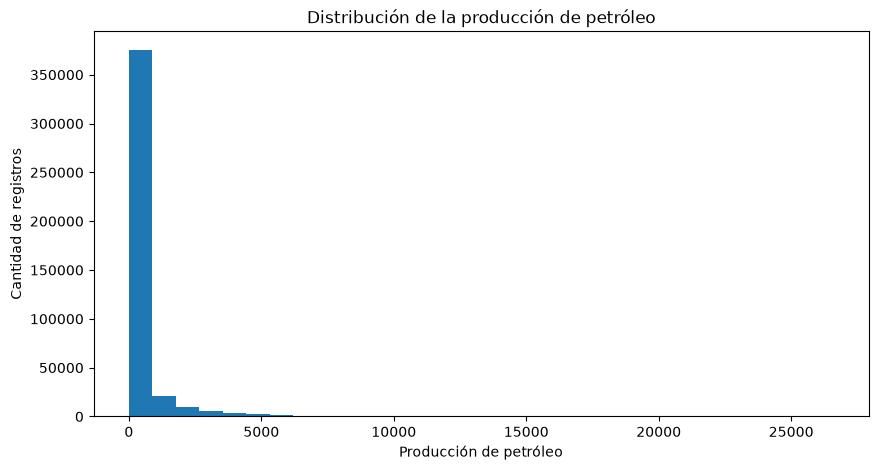

In [59]:
produccion["prod_pet"].plot(
    kind="hist",
    bins=30,
    figsize=(10, 5),
    title="Distribución de la producción de petróleo"
)

plt.xlabel("Producción de petróleo")
plt.ylabel("Cantidad de registros")
plt.show()

Los percentiles muestran que la producción de petróleo se encuentra fuertemente concentrada en valores bajos. La mediana es de 7,78, mientras que el 75% de los registros presenta una producción de hasta 122,29.

A medida que avanzamos hacia los percentiles superiores, los valores aumentan considerablemente: el 90% de los registros se encuentra por debajo de 991,74 y el 99% por debajo de 4.891,14. Sin embargo, el valor máximo alcanza 26.593,26.

Estos resultados indican que la variable `prod_pet` presenta una distribución sesgada hacia la derecha, con una concentración de registros en valores bajos y una cola formada por valores de producción considerablemente mayores.

El histograma completo permite observar la cola de la distribución, pero los valores más altos dificultan visualizar con detalle la zona donde se concentra la mayoría de los registros.

Para complementar el análisis, realizamos una segunda visualización considerando los registros hasta el percentil 99 de `prod_pet`. De esta manera podemos observar con mayor detalle el comportamiento de la gran mayoría de los registros sin eliminar estos valores del dataset original.

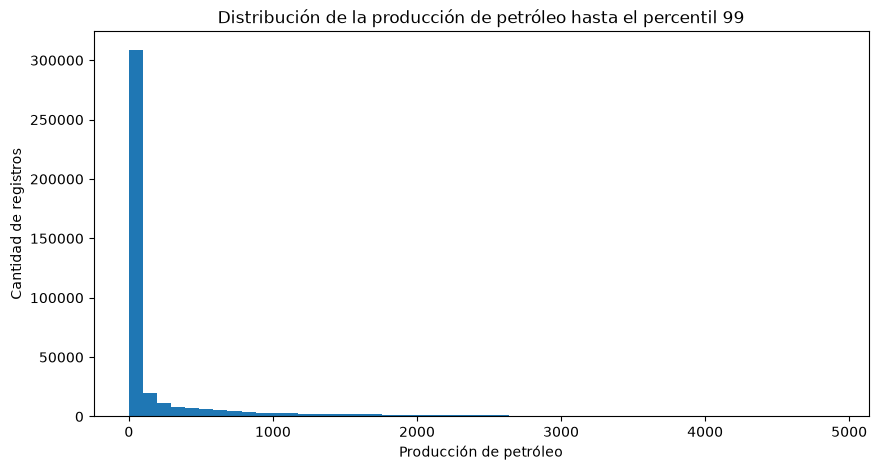

In [61]:
limite_p99 = produccion["prod_pet"].quantile(0.99)

produccion[produccion["prod_pet"] <= limite_p99]["prod_pet"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la producción de petróleo hasta el percentil 99"
)

plt.xlabel("Producción de petróleo")
plt.ylabel("Cantidad de registros")
plt.show()

La segunda visualización permite observar con mayor detalle la distribución de los valores que se encuentran dentro del 99% de los registros.

Se mantiene una concentración importante de observaciones en los valores bajos de producción y una disminución progresiva de la cantidad de registros a medida que aumenta la producción. Incluso al excluir de la visualización el 1% de los valores más altos, la distribución continúa presentando una marcada asimetría hacia la derecha.

Esto coincide con lo observado mediante los percentiles: mientras que el 75% de los registros tiene una producción de hasta 122,29, el 99% alcanza hasta 4.891,14. Por lo tanto, los valores elevados representan una proporción reducida del conjunto, pero generan una cola extensa en la distribución.

#### 3.4. Relación entre producción y estado del pozo

Hasta el momento analizamos las variables de forma individual. En esta etapa comenzamos a estudiar la relación entre ellas, tomando como referencia la producción de petróleo.

Primero analizamos cómo se distribuye `prod_pet` según el estado informado para cada registro. Esto nos permite comparar los niveles de producción entre los distintos estados y entender mejor la presencia de registros con producción nula o baja.


In [62]:
resumen_produccion_estado = (
    produccion
    .groupby("tipoestado")["prod_pet"]
    .agg(
        cantidad_registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .sort_values("cantidad_registros", ascending=False)
)

display(resumen_produccion_estado)

,cantidad_registros,promedio,mediana,minimo,maximo
tipoestado,,,,,
Extracción Efectiva,348150,399.987669,20.38,0.000,26593.261000
Parado Transitoriamente,26440,19.583350,0.00,0.000,7727.100000
En Estudio,23861,3.810864,0.00,-0.001,4245.405667
A Abandonar,3724,0.377167,0.00,0.000,1404.570000
Abandonado,3724,0.133939,0.00,0.000,380.320000
Otras Situación Inactivo,3252,27.497251,0.00,0.000,10261.700000
En Reserva de Gas,3074,3.453981,0.00,0.000,3153.820448
En Espera de Reparación,2685,0.203588,0.00,0.000,326.080000
Otras Situación Activo,2318,228.447469,0.00,0.000,12656.480000


Para complementar el resumen anterior, analizamos qué proporción de los registros de cada estado presenta producción de petróleo mayor que cero.

Esto permite diferenciar los estados en los que la producción es frecuente de aquellos en los que predominan registros con producción nula.


In [63]:
produccion_por_estado = (
    produccion
    .groupby("tipoestado")
    .agg(
        cantidad_registros=("prod_pet", "count"),
        registros_con_produccion=("prod_pet", lambda x: (x > 0).sum())
    )
)

produccion_por_estado["porcentaje_con_produccion"] = (
    produccion_por_estado["registros_con_produccion"]
    / produccion_por_estado["cantidad_registros"]
    * 100
)

produccion_por_estado = produccion_por_estado.sort_values(
    "cantidad_registros",
    ascending=False
)

display(produccion_por_estado)

,cantidad_registros,registros_con_produccion,porcentaje_con_produccion
tipoestado,,,
Extracción Efectiva,348150,269047,77.279046
Parado Transitoriamente,26440,2618,9.901664
En Estudio,23861,128,0.536440
A Abandonar,3724,1,0.026853
Abandonado,3724,3,0.080559
Otras Situación Inactivo,3252,43,1.322263
En Reserva de Gas,3074,8,0.260247
En Espera de Reparación,2685,4,0.148976
Otras Situación Activo,2318,812,35.030198


Los resultados muestran diferencias importantes entre los estados informados para los registros de producción.

`Extracción Efectiva` concentra la mayor cantidad de observaciones, con 348.150 registros, de los cuales el 77,28% presenta producción de petróleo mayor que cero. En cambio, `Parado Transitoriamente` tiene 26.440 registros, pero solo el 9,90% presenta producción positiva.

También se observa que `Otras Situación Activo` presenta un 35,03% de registros con producción positiva, aunque representa una cantidad de observaciones mucho menor que `Extracción Efectiva`.

En varios estados, como `Abandono Temporario`, `Parado Alta Relación Agua/Petróleo`, `En Reserva para Recup. Sec./Asist.`, `Parado Alta Relación Gas/Petróleo` y `Mantenimiento de Presión`, no se encontraron registros con producción de petróleo mayor que cero.

Estos resultados muestran que el estado informado está relacionado con la presencia de producción, aunque existen diferencias importantes entre categorías y algunas presentan muy pocas observaciones. Por este motivo, además de la cantidad de registros, es necesario analizar cómo se distribuyen los valores de producción dentro de cada estado.


##### 3.4.1. Análisis de los estados con mayor cantidad de registros

Como existen varios estados con cantidades de registros muy diferentes, para comparar la producción de forma más representativa nos enfocamos inicialmente en los seis estados con mayor cantidad de observaciones.

De esta manera evitamos que estados con muy pocos registros tengan el mismo peso en el análisis y podemos comparar el comportamiento de la producción entre las categorías más representativas del dataset.

Para cada uno de estos estados calculamos nuevamente la cantidad de registros, el promedio, la mediana y los valores mínimo y máximo de `prod_pet`.


In [64]:
estados_principales = (
    produccion["tipoestado"]
    .value_counts()
    .head(6)
    .index
)

resumen_estados_principales = (
    produccion[produccion["tipoestado"].isin(estados_principales)]
    .groupby("tipoestado")["prod_pet"]
    .agg(
        cantidad_registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .sort_values("cantidad_registros", ascending=False)
)

display(resumen_estados_principales)

,cantidad_registros,promedio,mediana,minimo,maximo
tipoestado,,,,,
Extracción Efectiva,348150,399.987669,20.38,0.000,26593.261000
Parado Transitoriamente,26440,19.583350,0.00,0.000,7727.100000
En Estudio,23861,3.810864,0.00,-0.001,4245.405667
A Abandonar,3724,0.377167,0.00,0.000,1404.570000
Abandonado,3724,0.133939,0.00,0.000,380.320000
Otras Situación Inactivo,3252,27.497251,0.00,0.000,10261.700000


##### 3.4.2. Distribución de la producción según el estado

Luego de comparar las estadísticas descriptivas de los principales estados, observamos diferencias importantes entre el promedio y la mediana de producción.

Para analizar estas diferencias de forma visual, utilizamos un diagrama de caja (boxplot) de `prod_pet` para los seis estados con mayor cantidad de registros.

Esta visualización permite comparar la mediana, la dispersión y la presencia de valores extremos entre los distintos estados.

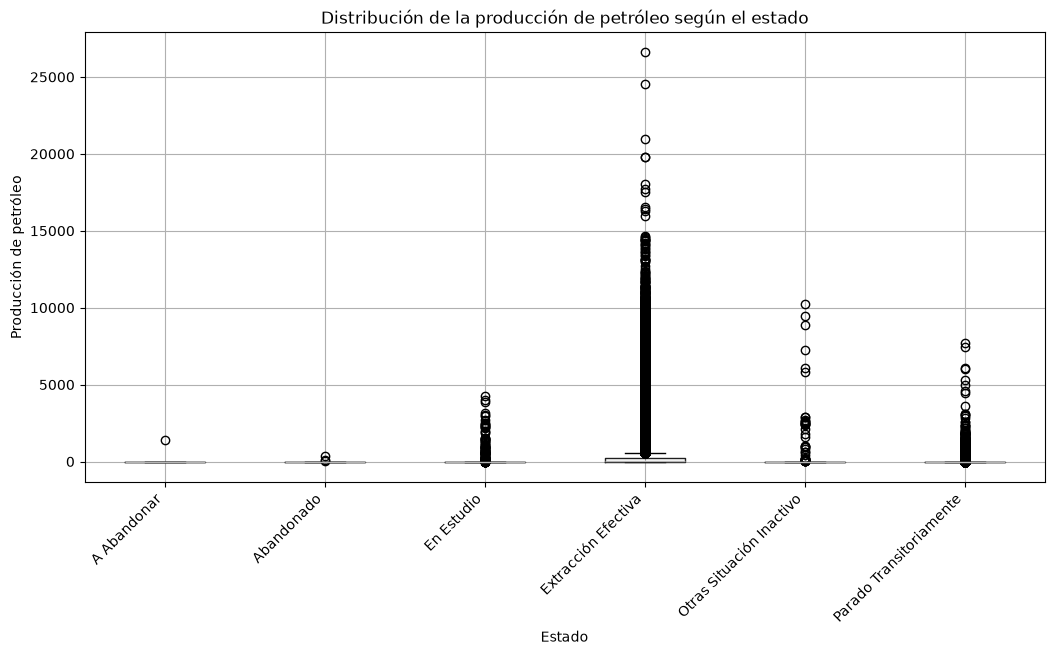

In [65]:
produccion_estados_principales = produccion[
    produccion["tipoestado"].isin(estados_principales)
]

produccion_estados_principales.boxplot(
    column="prod_pet",
    by="tipoestado",
    figsize=(12, 6)
)

plt.title("Distribución de la producción de petróleo según el estado")
plt.suptitle("")
plt.xlabel("Estado")
plt.ylabel("Producción de petróleo")
plt.xticks(rotation=45, ha="right")
plt.show()

El análisis de la producción según el estado muestra que `Extracción Efectiva` concentra la mayor cantidad de registros y presenta una proporción considerablemente mayor de observaciones con producción positiva respecto del resto de los estados analizados.

También observamos que las medianas de los principales estados se encuentran muy próximas a cero, mientras que los promedios son considerablemente mayores. Esto confirma nuevamente la fuerte asimetría de `prod_pet` y la presencia de una cola de valores elevados.

El boxplot permite observar este comportamiento, aunque la gran diferencia entre los valores bajos y los valores máximos dificulta la comparación visual entre algunas categorías. Por este motivo, para los siguientes análisis será importante considerar medidas robustas como la mediana y utilizar visualizaciones adecuadas para distribuciones sesgadas.

A partir de este análisis, `tipoestado` se presenta como una variable potencialmente relevante para explicar diferencias en la producción, aunque su utilización en el modelo deberá evaluarse posteriormente teniendo en cuenta la información disponible en el momento de realizar cada predicción.


#### 3.5. Relación entre producción y cuenca

Luego de analizar el estado de los registros, estudiamos la relación entre la producción de petróleo y la cuenca a la que pertenece cada pozo.

La variable `cuenca` permite incorporar información sobre el contexto geográfico y productivo de los pozos. Primero analizaremos la cantidad de registros y el comportamiento de `prod_pet` en cada cuenca, utilizando medidas como el promedio y la mediana.

Esto nos permitirá determinar si existen diferencias importantes en los niveles de producción entre las distintas cuencas antes de realizar una comparación visual.


In [66]:
resumen_produccion_cuenca = (
    produccion
    .groupby("cuenca")["prod_pet"]
    .agg(
        cantidad_registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .sort_values("cantidad_registros", ascending=False)
)

display(resumen_produccion_cuenca)

,cantidad_registros,promedio,mediana,minimo,maximo
cuenca,,,,,
NEUQUINA,404037,346.620817,7.20497,0.000,26593.26100
AUSTRAL,16197,19.084589,11.53400,-0.001,543.93500
GOLFO SAN JORGE,627,198.833239,90.14111,0.000,1431.11600
NOROESTE,185,86.331332,0.00000,0.000,387.14578


##### 3.5.1. Distribución de la producción según cuenca

El resumen anterior muestra diferencias entre las cuencas, especialmente al comparar las medianas y los promedios de producción.

Para observar estas diferencias de manera visual, analizamos la distribución de `prod_pet` para cada cuenca mediante un diagrama de caja. Esta visualización permite comparar las medianas, la dispersión de los valores y la presencia de valores elevados dentro de cada grupo.

Debido a que la producción presenta una distribución fuertemente sesgada, debemos tener en cuenta que los valores extremos pueden afectar la escala del gráfico.


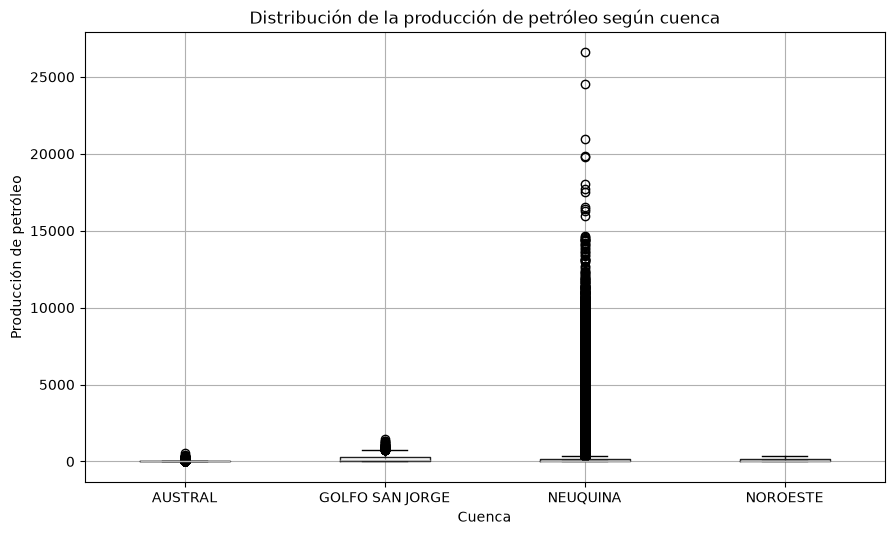

In [67]:
produccion.boxplot(
    column="prod_pet",
    by="cuenca",
    figsize=(10, 6)
)

plt.title("Distribución de la producción de petróleo según cuenca")
plt.suptitle("")
plt.xlabel("Cuenca")
plt.ylabel("Producción de petróleo")
plt.show()

##### 3.5.2. Conclusiones del análisis por cuenca

El análisis muestra diferencias entre las cuencas en los niveles de producción de petróleo. En particular, `GOLFO SAN JORGE` presenta una mediana de 90,14, mientras que `NEUQUINA` presenta una mediana de 7,20. `AUSTRAL` tiene una mediana de 11,53 y `NOROESTE` presenta una mediana de 0.

También se observa una diferencia importante entre los promedios y las medianas, especialmente en `NEUQUINA`, donde el promedio alcanza 346,62 mientras que la mediana es 7,20. Esto vuelve a mostrar la fuerte asimetría de la variable `prod_pet` y el efecto de los valores de producción elevados.

La visualización mediante boxplot permite observar esta asimetría, aunque la gran diferencia de escala entre los valores dificulta la comparación visual entre algunas cuencas. Por este motivo, para análisis posteriores será necesario complementar este tipo de gráficos con estadísticas descriptivas y otras visualizaciones.

Además, las cantidades de registros son muy diferentes entre las cuencas. `NEUQUINA` concentra 404.037 registros, mientras que `GOLFO SAN JORGE` y `NOROESTE` tienen una cantidad considerablemente menor. Por lo tanto, las diferencias observadas en estas últimas deben interpretarse teniendo en cuenta su menor representación en el dataset.

En función de estos resultados, `cuenca` se considera una variable potencialmente relevante para caracterizar la producción y podría ser evaluada posteriormente como variable predictora.


#### 3.6. Relación entre producción y formación

Luego de analizar la relación entre producción y cuenca, estudiamos la variable `formacion`, que describe la formación geológica asociada a cada registro.

El dataset contiene numerosas formaciones con cantidades de registros muy diferentes. Por este motivo, antes de comparar su producción, analizamos cómo se distribuyen los registros entre las distintas formaciones.

Esto nos permitirá identificar cuáles tienen una representación suficiente para realizar comparaciones y evitar conclusiones basadas en categorías con muy pocas observaciones.


In [68]:
registros_por_formacion = (
    produccion["formacion"]
    .value_counts()
    .rename("cantidad_registros")
)

display(registros_por_formacion)

formacion
vaca muerta               216445
lajas                      77407
mulichinco                 34749
los molles                 28011
magallanes                 15605
precuyo                    14603
quintuco                   10958
punta rosada                9577
agrio                       5671
basamento                   2172
lotena                      1595
formación improductiva       711
tordillo                     517
sierras blancas              466
chachao                      407
centenario                   404
pozo d-129                   385
ANITA                        209
palermo aike                 206
rayoso                       187
yacoraite                    185
springhill                   159
grupo chubut                 151
loma montosa                 126
mina el carmen                38
cañadon seco                  32
grupo neuquén                 31
bajo barreal                  21
tobífera                      18
Name: cantidad_registros, dtype: 

##### 3.6.1. Producción de petróleo según formación

Luego de conocer cómo se distribuyen los registros entre las distintas formaciones, analizamos el comportamiento de la producción de petróleo en cada una de ellas.

Para esto agrupamos los registros según formacion y calculamos la cantidad de observaciones, el promedio, la mediana y los valores mínimo y máximo de prod_pet.

La cantidad de registros nos permite conocer qué tan representada está cada formación, mientras que el promedio y la mediana nos permiten comparar sus niveles de producción. Incluimos ambas medidas porque anteriormente observamos que prod_pet presenta una distribución sesgada, por lo que el promedio puede verse afectado por valores de producción elevados.

In [70]:
resumen_produccion_formacion = (
    produccion
    .groupby("formacion")["prod_pet"]
    .agg(
        cantidad_registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .sort_values("cantidad_registros", ascending=False)
)

display(resumen_produccion_formacion)

,cantidad_registros,promedio,mediana,minimo,maximo
formacion,,,,,
vaca muerta,216445,625.970863,69.680000,0.00000,26593.26100
lajas,77407,33.298582,0.088252,0.00000,3511.23100
mulichinco,34749,11.902193,0.460000,0.00000,1108.21600
los molles,28011,6.200870,1.230000,0.00000,667.17000
magallanes,15605,19.394056,11.851030,-0.00100,543.93500
precuyo,14603,10.294439,0.000000,0.00000,1205.81000
quintuco,10958,16.941804,0.000000,0.00000,4428.59000
punta rosada,9577,94.810026,24.990000,0.00000,2890.50000
agrio,5671,15.427872,0.000000,0.00000,1936.78000


##### 3.6.2. Selección de formaciones representativas

El análisis anterior muestra que la cantidad de registros varía considerablemente entre las distintas formaciones. Mientras que algunas concentran miles de observaciones, otras presentan una cantidad muy reducida de registros.

Para realizar una comparación visual más representativa, seleccionamos inicialmente las 10 formaciones con mayor cantidad de registros. Esta selección no implica descartar las demás categorías del dataset, sino limitar el análisis visual a aquellas que cuentan con una mayor representación.

Antes de continuar, calculamos qué proporción del total de registros representan estas formaciones para conocer qué tan representativo es este subconjunto.


##### 3.6.1. Formaciones más representadas

El análisis anterior muestra que existen numerosas formaciones dentro del dataset, pero la cantidad de registros no se distribuye de manera uniforme.

Algunas formaciones concentran una gran cantidad de observaciones, mientras que otras tienen una representación muy reducida. Por este motivo, para continuar con el análisis nos enfocamos inicialmente en las formaciones con mayor cantidad de registros.

Esto permite realizar comparaciones con una cantidad de observaciones suficiente y evita darle el mismo peso a categorías con diferencias muy grandes en su representación.


In [71]:
top_10_formaciones = resumen_produccion_formacion.head(10)

cantidad_top_10 = top_10_formaciones["cantidad_registros"].sum()
cantidad_total = len(produccion)

porcentaje_top_10 = cantidad_top_10 / cantidad_total * 100

print("Cantidad de registros de las 10 principales formaciones:", cantidad_top_10)
print(f"Porcentaje del total de registros: {porcentaje_top_10:.2f}%")

Cantidad de registros de las 10 principales formaciones: 415198
Porcentaje del total de registros: 98.61%


##### 3.6.3. Mediana de producción según formación

Luego de seleccionar las formaciones con mayor representación, comparamos la producción de petróleo entre ellas utilizando la mediana de `prod_pet`.

Elegimos la mediana como medida principal porque el análisis anterior mostró que la producción presenta una distribución fuertemente sesgada hacia la derecha. En este contexto, la mediana resulta menos sensible a los valores de producción muy elevados que el promedio.

De esta manera podemos observar con mayor claridad las diferencias en el nivel de producción habitual entre las formaciones más representadas.


In [72]:
mediana_por_formacion = (
    top_10_formaciones
    .sort_values("mediana", ascending=False)
)

display(mediana_por_formacion[["cantidad_registros", "mediana"]])

,cantidad_registros,mediana
formacion,,
vaca muerta,216445,69.680000
punta rosada,9577,24.990000
magallanes,15605,11.851030
basamento,2172,1.375000
los molles,28011,1.230000
mulichinco,34749,0.460000
lajas,77407,0.088252
precuyo,14603,0.000000
quintuco,10958,0.000000


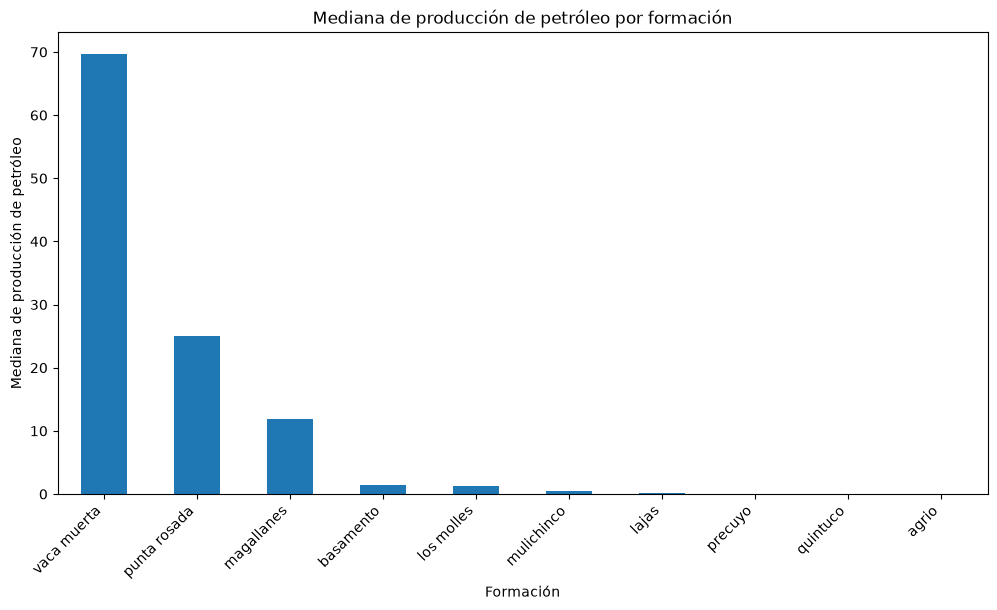

In [74]:
mediana_por_formacion["mediana"].plot(
    kind="bar",
    figsize=(12, 6),
    title="Mediana de producción de petróleo por formación"
)

plt.xlabel("Formación")
plt.ylabel("Mediana de producción de petróleo")
plt.xticks(rotation=45, ha="right")
plt.show()

##### 3.6.4. Producción positiva según formación

El análisis de la mediana mostró que algunas de las formaciones más representadas presentan una mediana de producción igual o cercana a cero.

Para comprender mejor este comportamiento, analizamos la cantidad y el porcentaje de registros que presentan producción de petróleo mayor a cero en cada formación.

Este análisis permite distinguir entre formaciones donde la mayoría de los registros presentan alguna producción y aquellas donde los registros con producción positiva representan una proporción menor.

De esta manera podemos interpretar mejor las medianas obtenidas anteriormente, sin asumir que los registros con producción igual a cero corresponden necesariamente a pozos inactivos o a un problema en los datos.


In [75]:
produccion_por_formacion = (
    produccion
    .groupby("formacion")
    .agg(
        cantidad_registros=("prod_pet", "count"),
        registros_con_produccion=("prod_pet", lambda x: (x > 0).sum())
    )
)

produccion_por_formacion["porcentaje_con_produccion"] = (
    produccion_por_formacion["registros_con_produccion"]
    / produccion_por_formacion["cantidad_registros"]
    * 100
)

produccion_por_formacion = produccion_por_formacion.sort_values(
    "cantidad_registros",
    ascending=False
)

display(produccion_por_formacion)

,cantidad_registros,registros_con_produccion,porcentaje_con_produccion
formacion,,,
vaca muerta,216445,158079,73.034258
lajas,77407,39692,51.277016
mulichinco,34749,20265,58.318225
los molles,28011,17128,61.147406
magallanes,15605,13623,87.298943
precuyo,14603,5749,39.368623
quintuco,10958,5261,48.010586
punta rosada,9577,7543,78.761616
agrio,5671,2473,43.607829


##### 3.6.5. Producción positiva según formación

El análisis anterior permitió observar que la proporción de registros con producción positiva varía considerablemente entre las formaciones.

Sin embargo, este indicador no muestra cuánto petróleo producen los registros cuando efectivamente existe producción. Por este motivo, en este análisis filtramos los registros con `prod_pet > 0` y calculamos nuevamente la cantidad de observaciones, el promedio, la mediana y los valores mínimo y máximo para cada formación.

De esta manera podemos diferenciar dos aspectos del comportamiento productivo: la frecuencia con la que se registra producción y el nivel de producción observado cuando esta es positiva.


In [76]:
produccion_positiva = produccion[produccion["prod_pet"] > 0]

resumen_produccion_positiva_formacion = (
    produccion_positiva
    .groupby("formacion")["prod_pet"]
    .agg(
        cantidad_registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .sort_values("cantidad_registros", ascending=False)
)

display(resumen_produccion_positiva_formacion)

,cantidad_registros,promedio,mediana,minimo,maximo
formacion,,,,,
vaca muerta,158079,857.092109,276.440000,0.001053,26593.26100
lajas,39692,64.938612,17.502000,0.004011,3511.23100
mulichinco,20265,20.409045,5.350000,0.000001,1108.21600
los molles,17128,10.140856,3.780000,0.009522,667.17000
magallanes,13623,22.215682,14.222950,0.010000,543.93500
punta rosada,7543,120.375927,46.900000,0.000002,2890.50000
precuyo,5749,26.148842,9.020853,0.010000,1205.81000
quintuco,5261,35.287644,9.600000,0.001264,4428.59000
agrio,2473,35.378674,2.172183,0.000009,1936.78000


##### 3.6.6. Comparación de las formaciones más representadas

Luego de analizar la proporción de registros con producción positiva y el comportamiento de `prod_pet` cuando la producción es mayor a cero, comparamos las 10 formaciones con mayor cantidad de registros.

Para esta comparación utilizamos la mediana de `prod_pet` considerando únicamente los registros con producción positiva. De esta manera evitamos que la presencia de registros con producción igual a cero oculte las diferencias en los niveles de producción observados cuando existe producción.

La comparación se limita a las 10 formaciones más representadas para evitar que categorías con muy pocas observaciones condicionen la interpretación.


In [77]:
top_10_positivas = (
    resumen_produccion_positiva_formacion
    .loc[top_10_formaciones.index]
    .sort_values("mediana", ascending=False)
)

display(
    top_10_positivas[
        ["cantidad_registros", "mediana"]
    ]
)

,cantidad_registros,mediana
formacion,,
vaca muerta,158079,276.440000
punta rosada,7543,46.900000
lajas,39692,17.502000
magallanes,13623,14.222950
quintuco,5261,9.600000
precuyo,5749,9.020853
mulichinco,20265,5.350000
basamento,1299,4.880000
los molles,17128,3.780000


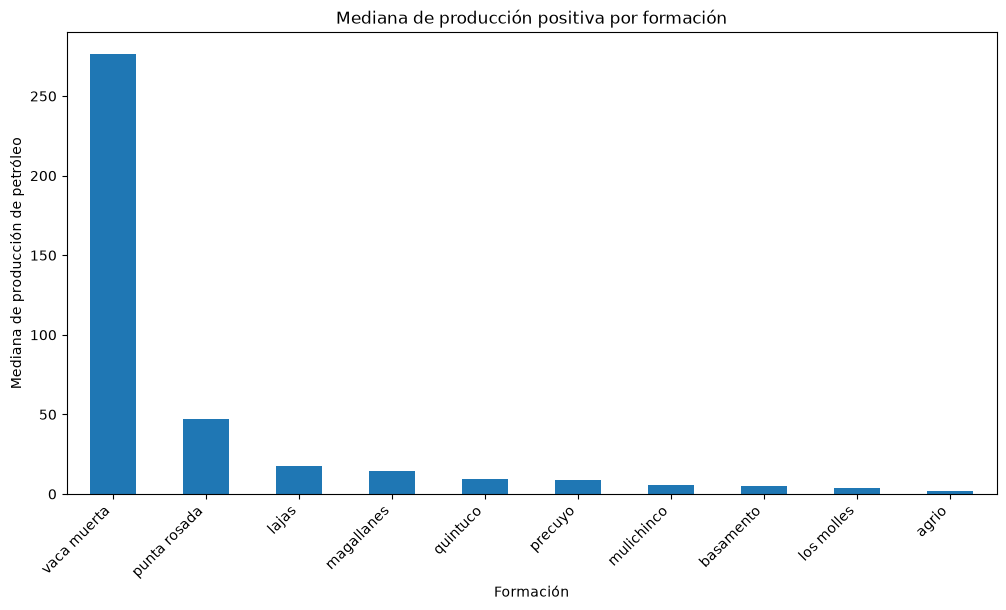

In [78]:
top_10_positivas["mediana"].plot(
    kind="bar",
    figsize=(12, 6),
    title="Mediana de producción positiva por formación"
)

plt.xlabel("Formación")
plt.ylabel("Mediana de producción de petróleo")
plt.xticks(rotation=45, ha="right")
plt.show()

##### 3.6.7. Conclusiones del análisis por formación

El análisis de la variable `formacion` muestra diferencias importantes tanto en la cantidad de registros disponibles como en el comportamiento de la producción de petróleo.

`Vaca Muerta` es la formación con mayor representación en el dataset, con 216.445 registros. Además, el 73,03% de sus registros presenta producción de petróleo positiva y, considerando únicamente estos registros, la mediana de producción alcanza 276,44.

También se observan diferencias entre otras formaciones. Por ejemplo, `Punta Rosada` presenta un 78,76% de registros con producción positiva y una mediana de producción positiva de 46,90, mientras que `Lajas` presenta un 51,28% de registros con producción positiva y una mediana positiva de 17,50.

Por otro lado, algunas formaciones presentan valores elevados de producción positiva pero cuentan con una cantidad de registros mucho menor. Por este motivo, sus resultados deben interpretarse con mayor cautela y no compararse directamente con formaciones que tienen una representación mucho mayor.

En conjunto, los resultados muestran que `formacion` contiene información que podría ser relevante para explicar diferencias en el comportamiento de la producción de petróleo. Sin embargo, para el desarrollo del modelo será necesario considerar también otras variables y, especialmente, la información histórica disponible hasta el momento de realizar cada predicción.
